<a href="https://colab.research.google.com/github/ludmila-sla/aulas-mestrado/blob/main/adaline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


class Adaline:
    def __init__(self, lr=0.01, epochs=100, epsilon=0.001, mode='batch', seed=None):
        self.lr = lr
        self.epochs = epochs
        self.epsilon = epsilon
        self.mode = mode
        self.seed = seed
        self.w = None
        self.mse_history = []
        self.error_history = []

    def _add_bias(self, X):
        bias = np.ones((1, X.shape[1]))
        return np.vstack((bias, X))

    def _step(self, x):
        return np.where(x >= 0, 1, -1)

    def fit(self, X, y):
        if self.seed:
            np.random.seed(self.seed)

        X = self._add_bias(X)
        n_features, n_samples = X.shape

        self.w = np.random.randn(n_features, 1)

        for epoch in range(self.epochs):
            if self.mode == 'batch':
                u = self.w.T @ X
                error = y - u

                self.w += self.lr * (1/n_samples) * (X @ error.T)

            else:
                for i in range(n_samples):
                    xi = X[:, i].reshape(-1, 1)
                    yi = y[0, i]

                    u = self.w.T @ xi
                    error = yi - u

                    self.w += self.lr * error * xi

            u_all = self.w.T @ X
            mse = np.mean((y - u_all) ** 2)

            y_pred = self._step(u_all)
            class_error = np.mean(y_pred != y)

            self.mse_history.append(mse)
            self.error_history.append(class_error)

            if mse < self.epsilon:
                break

    def predict(self, X):
        X = self._add_bias(X)
        u = self.w.T @ X
        return self._step(u)

    def accuracy(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def plot_decision_boundary(X, y, model, title):
    plt.scatter(X[0, :], X[1, :], c=y.flatten())

    x_vals = np.linspace(X[0, :].min(), X[0, :].max(), 100)
    w0, w1, w2 = model.w.flatten()

    y_vals = -(w0 + w1 * x_vals) / w2

    plt.plot(x_vals, y_vals, color='red')
    plt.title(title)
    plt.show()

Treino: 0.9285714285714286
Teste: 0.9166666666666666


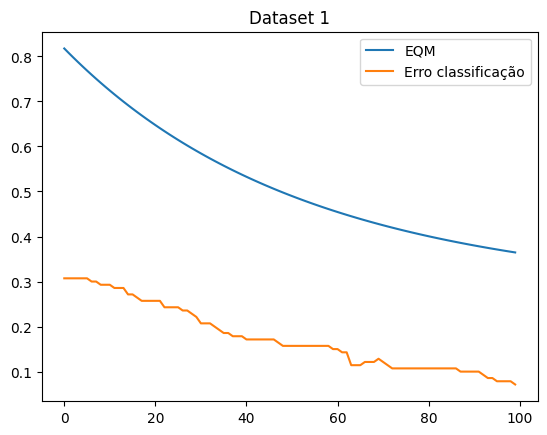

In [ ]:

df_train = pd.read_csv('/content/drive/MyDrive/trabalho perception/train_dataset1.csv')
df_test = pd.read_csv('/content/drive/MyDrive/trabalho perception/test_dataset1.csv')

X_train = df_train.drop('label', axis=1).values.T
y_train = df_train['label'].values.reshape(1, -1)

X_test = df_test.drop('label', axis=1).values.T
y_test = df_test['label'].values.reshape(1, -1)

model = Adaline(lr=0.01, epochs=100, epsilon=0.001, mode='batch', seed=42)
model.fit(X_train, y_train)

print("Treino:", model.accuracy(X_train, y_train))
print("Teste:", model.accuracy(X_test, y_test))

plt.plot(model.mse_history, label="EQM")
plt.plot(model.error_history, label="Erro classificação")
plt.legend()
plt.title("Dataset 1")
plt.show()



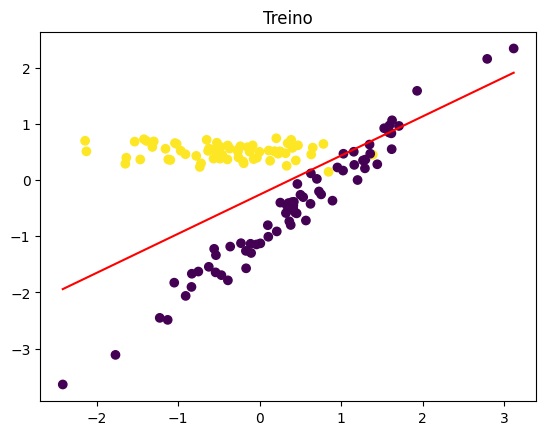

In [ ]:
plot_decision_boundary(X_train, y_train, model, "Treino")


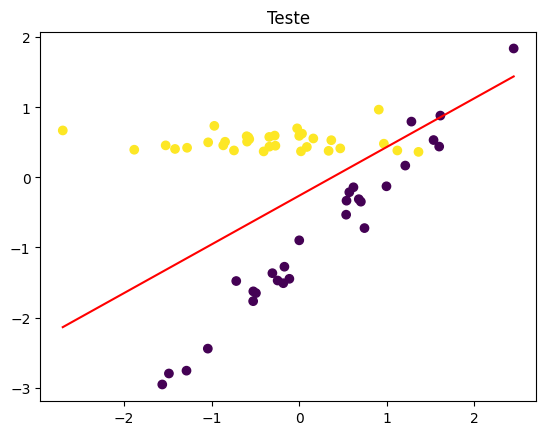

In [ ]:
plot_decision_boundary(X_test, y_test, model, "Teste")

No Dataset 1, o modelo Adaline apresentou acurácia de aproximadamente 92,8% no treino e 91,6% no teste. Esse resultado é semelhante ao obtido com o Perceptron, indicando que os dados são aproximadamente linearmente separáveis. Nesse cenário, ambos os modelos conseguem encontrar uma boa fronteira de decisão, apresentando alto desempenho e boa capacidade de generalização.

# Dataset 2

Treino: 0.68
Teste: 0.7466666666666667


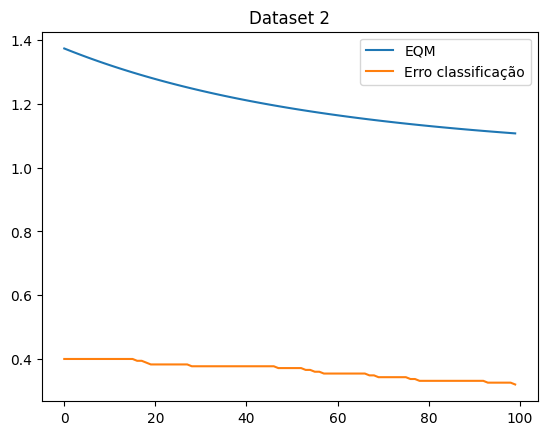

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/trabalho perception/train_dataset2.csv')
df_test = pd.read_csv('/content/drive/MyDrive/trabalho perception/test_dataset2.csv')

X_train = df_train.drop('label', axis=1).values.T
y_train = df_train['label'].values.reshape(1, -1)

X_test = df_test.drop('label', axis=1).values.T
y_test = df_test['label'].values.reshape(1, -1)

model = Adaline(lr=0.01, epochs=100, epsilon=0.001, mode='batch', seed=42)
model.fit(X_train, y_train)

print("Treino:", model.accuracy(X_train, y_train))
print("Teste:", model.accuracy(X_test, y_test))

plt.plot(model.mse_history, label="EQM")
plt.plot(model.error_history, label="Erro classificação")
plt.legend()
plt.title("Dataset 2")
plt.show()


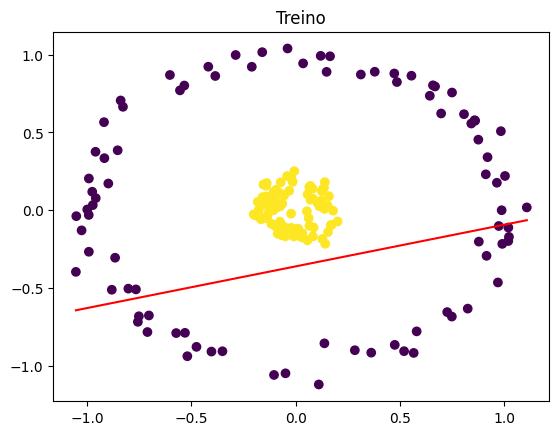

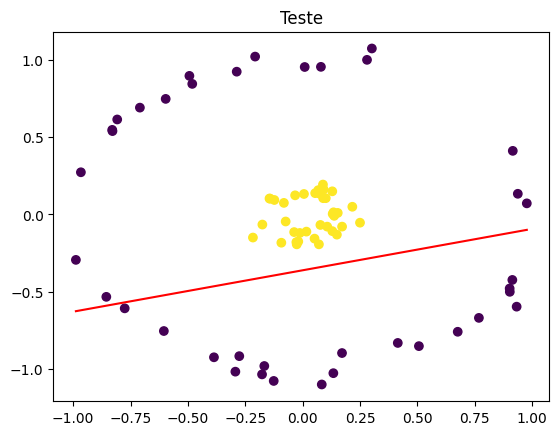

In [ ]:

plot_decision_boundary(X_train, y_train, model, "Treino")
plot_decision_boundary(X_test, y_test, model, "Teste")

No Dataset 2, o Adaline obteve acurácia de aproximadamente 68% no treino e 74,6% no teste. Comparado ao Perceptron, houve uma melhora no desempenho, especialmente no conjunto de teste. Isso ocorre porque, mesmo em um cenário não linearmente separável, o Adaline consegue minimizar o erro quadrático médio, encontrando uma solução aproximada mais estável. Ainda assim, o modelo permanece limitado por sua natureza linear.

# dataset 3

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/trabalho perception/train_dataset3.csv')
df_test = pd.read_csv('/content/drive/MyDrive/trabalho perception/test_dataset3.csv')

X_train = df_train.drop('label', axis=1).values.T
y_train = df_train['label'].values.reshape(1, -1)

X_test = df_test.drop('label', axis=1).values.T
y_test = df_test['label'].values.reshape(1, -1)

lr=0.01, eps=0.1 -> treino=0.6735, teste=0.5873
lr=0.01, eps=0.0001 -> treino=0.6735, teste=0.5873
lr=0.001, eps=0.1 -> treino=0.4354, teste=0.3651
lr=0.001, eps=0.0001 -> treino=0.4354, teste=0.3651
lr=0.0001, eps=0.1 -> treino=0.4218, teste=0.3333
lr=0.0001, eps=0.0001 -> treino=0.4218, teste=0.3333


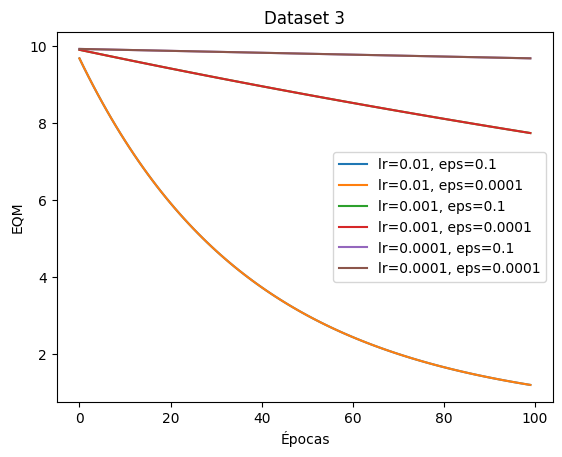

In [ ]:
learning_rates = [0.01, 0.001, 0.0001]
epsilons = [0.1, 0.0001]

results = []
for lr in learning_rates:
    for eps in epsilons:
        model = Adaline(lr=lr, epochs=100, epsilon=eps, mode='batch', seed=42)
        model.fit(X_train, y_train)

        train_acc = model.accuracy(X_train, y_train)
        test_acc = model.accuracy(X_test, y_test)

        results.append((lr, eps, train_acc, test_acc))

        print(f"lr={lr}, eps={eps} -> treino={train_acc:.4f}, teste={test_acc:.4f}")

        plt.plot(model.mse_history, label=f"lr={lr}, eps={eps}")

plt.xlabel("Épocas")
plt.ylabel("EQM")
plt.legend()
plt.title("Dataset 3")
plt.show()

No Dataset 3, os resultados variaram conforme a taxa de aprendizado. Para valores mais altos (lr = 0.01), o modelo apresentou melhor desempenho, enquanto taxas menores resultaram em queda significativa na acurácia, chegando a valores próximos de 33% no conjunto de teste.

Diferentemente do Perceptron, o Adaline apresentou comportamento mais estável ao longo das execuções, com menor variação entre os resultados, devido ao uso do erro quadrático médio como critério de otimização.

No entanto, essa maior estabilidade não implicou em melhor desempenho, evidenciando as limitações do modelo em lidar com dados mais complexos e de maior dimensionalidade.

Além disso, o critério de parada não influenciou os resultados, uma vez que o erro não atingiu os valores definidos, fazendo com que o treinamento fosse executado até o número máximo de épocas em todos os casos.